# DWD Weather Data

## Setup for EDA and time series 

In [1]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
##
##
import glob
import json
import re
import os
##

## Plotting Functions

In [2]:
def simple_lineplot(df, y, x="MESS_DATUM"):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
    ax.set(title='target_weather_historical_daily', ylabel=y)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [3]:
def average_lineplot(df, y, x='MESS_DATUM', time='year', group='STATIONS_ID'):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ax.set(title='Average target_weather_historical_daily', ylabel=y);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()

def average_lineplot_no_group(df, y, x='MESS_DATUM', time='year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax)
    ax.set(title='Average target_weather_historical_daily', ylabel=y);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()

## Data overview

### Details daily weather data from the following sources  

- weather-daily/KL_climate_historical_daily

- weather-daily/KL_climate_recent_daily

- weather-daily/phenomena_historical_daily

- weather-daily/phenomena_recent_daily  (this data is not available)

- weather-daily/RR_morephenomena_historical_daily

- weather-daily/RR_morephenomena_recent_daily (this data is not available)

### Paths to 'weather-daily' data folder

In [4]:
path_KL_climate_historical_  = '../data/weather-daily/KL_climate_historical_daily/*.txt'
path_KL_climate_recent_  = '../data/weather-daily/KL_climate_recent_daily/*.txt'
path_KL_climate_phenomena_historical_  = '../data/weather-daily/phenomena_historical_daily/*.txt'
#path_KL_climate_phenomena_recent_daily   = '../data/weather-daily/phenomena_recent_daily/*.txt' # no data
path_KL_climate_morephenomena_historical_ = '../data/weather-daily/RR_morephenomena_historical_daily/*.txt'
#path_KL_climate_morephenomena_recent_daily  = '../data/weather-daily/RR_morephenomena_recent_daily/*.txt' # no data

### Columns descriptions  of weather-daily/KL_climate_recent_daily
|column name               | Description             | uom           | Type        | format   |
|---------------------| ---------------------|-----------------------------------------|---------------------|--------------------- |
|STATIONS_ID| Station ID|          |            |VARCHAR2|     
|MESS_DATUM| reference date ||| NUMBER|YYYYMMDD |
|QN_3               |quality level of the following columns              |       | NUMBER        | numerical code  |
|FX               |daily maximum of windgust           |  m/s       |NUMBER         | 9990.0 |
|FM               |daily mean of wind velocity            | m/s     |  NUMBER     |  9990.0 | 
|QN_4              |quality level of the following columns           |     |  NUMBER    |  numerical code | 
|RSK             |daily precipitation height          |  mm   |  NUMBER    |  9990.0 | 
|RSKF             |precipitation form          |numerical code   |NUMBER   |  | 
|SDK            |daily sunshine duration         |h   |NUMBER   |9990.0  | 
|SHK_TAG            |daily snow depth        |cm   |NUMBER   |9990.0 | 
|NM           |daily mean of cloud cover       |1/8   |NUMBER   |9990.0 | 
|VPM           |daily mean of vapor pressure       |hPa   |NUMBER   |9990.0 | 
|PM          |daily mean of pressure      |hPa   |NUMBER   |9990.0 | 
|TMK          |daily mean of temperature      |°C   |NUMBER   |9990.0 |
|TMK          |daily mean of temperature      |°C   |NUMBER   |9990.0 |
|UPM         |daily mean of relative humidity      |%   |NUMBER   |9990.0 |
|TXK        |daily maximum of temperature at 2 m height      |°C  |NUMBER   |9990.0 |
|TNK        |daily minimum of temperature at 2m height      |°C  |NUMBER   |9990.0 |
|TGK       |daily minimum of air temperature at 5 cm above ground      |°C  |NUMBER   |9990.0 |

- Parameter: form of precipitation, air temperature at 2 m, precipitation parameters, precipitation height, wind velocity, cloud coverage, snow depth, sunshine duration, air temperature near ground, kind of precipitation, wind gust, air pressure at station level, vapor pressure, relative humidity 

- Unit(s) eighth, °C, %, m/s, hPa, cm, beaufort, mm

### Quality Information
The QUALITAETS_NIVEAU (QN) shows the quality control procedure applied parameters) for a certain reporting time.
for a data report (of several parameters) for a certain reporting time.

Data before and including 1980 can reach as best quality check level QN=5. Data after 1980 can reach QN=10 as best quality check level.


- QN = 1 : only formal control;
- QN = 2 : controlled with individually defined criteria;
- QN = 3 : automatic control and correction;
- QN = 5 : historic, subjective procedures;
- QN = 7 : second control done, before correction;
- QN = 8 : quality control outside ROUTINE;
- QN = 9 : not all parameters corrected;
- QN = 10 : quality control finished, all corrections finished.


The QUALITAETS_BYTE (QB) denotes whether the value was objected to and/or corrected.

- QB = 0 : denotes not flagged,
- QB = 1 : had no objections (either checked and not objected, or not checked and not objected, this can be interpreted only when considering QN);
- QB = 2 : corrected;
- QB = 3 : confirmed with objection rejected;
- QB = 4 : added or calculated;
- QB = 5 : objected;
- QB = 6 : only formally checked;
- QB = 7 : formal objection;
- QB = -999 : quality flag does not exist.

## 'KL_climate_daily' - data import and preprocessing 

In [5]:
# Get a list of all CSV files in a directory
# Sorted will append files in alphabetical order from 000 to last
txt_files =  sorted(glob.glob(path_KL_climate_historical_), reverse=False)
txt_files.extend(sorted(glob.glob(path_KL_climate_recent_), reverse=False))

# Create an empty list to store the data from each txt file
main_KLch_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, sep = ";")#'ISO-8859-1')
    print(file, df.shape)
    # Append the DataFrame to the list
    main_KLch_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
KL_climate_df = pd.concat(main_KLch_df, ignore_index=False).reset_index(drop=True) #KL_climate_his = pd.concat(main_df, axis=1)
#KL_climate_df.to_csv('../data/weather-daily/KL_climate_historical_daily/Weather_KL_climate_historical_daily.csv')
#KL_climate_df.to_csv('../data/Weather_KL_climate_historical_daily.csv')

../data/weather-daily/KL_climate_historical_daily/produkt_klima_tag_18600101_20221231_01684.txt (57802, 19)
../data/weather-daily/KL_climate_historical_daily/produkt_klima_tag_19590701_20221231_02712.txt (23195, 19)
../data/weather-daily/KL_climate_recent_daily/produkt_klima_tag_20220116_20230719_01684.txt (550, 19)
../data/weather-daily/KL_climate_recent_daily/produkt_klima_tag_20220116_20230719_02712.txt (550, 19)
4
82097


In [6]:
# replace leading spaces in column titles
KL_climate_df.columns = KL_climate_df.columns.str.replace(" ", "")
KL_climate_df.columns, KL_climate_df.shape

(Index(['STATIONS_ID', 'MESS_DATUM', 'QN_3', 'FX', 'FM', 'QN_4', 'RSK', 'RSKF',
        'SDK', 'SHK_TAG', 'NM', 'VPM', 'PM', 'TMK', 'UPM', 'TXK', 'TNK', 'TGK',
        'eor'],
       dtype='object'),
 (82097, 19))

In [7]:
KL_climate_df.head()

,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,QN_4,RSK,RSKF,SDK,SHK_TAG,NM,VPM,PM,TMK,UPM,TXK,TNK,TGK,eor
0,1684,18600101,-999,-999.0,-999.0,1,-999.0,-999,-999.0,-999,-999.0,10.5,987.6,9.4,91.0,-999.0,-999.0,-999.0,eor
1,1684,18600102,-999,-999.0,-999.0,1,-999.0,-999,-999.0,-999,-999.0,7.6,988.5,8.2,72.0,-999.0,-999.0,-999.0,eor
2,1684,18600103,-999,-999.0,-999.0,1,-999.0,-999,-999.0,-999,-999.0,6.9,983.1,6.0,75.0,-999.0,-999.0,-999.0,eor
3,1684,18600104,-999,-999.0,-999.0,1,-999.0,-999,-999.0,-999,-999.0,6.3,967.5,3.4,80.0,-999.0,-999.0,-999.0,eor
4,1684,18600105,-999,-999.0,-999.0,1,-999.0,-999,-999.0,-999,-999.0,6.1,958.2,3.7,80.0,-999.0,-999.0,-999.0,eor


In [8]:
KL_climate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82097 entries, 0 to 82096
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   STATIONS_ID  82097 non-null  int64  
 1   MESS_DATUM   82097 non-null  int64  
 2   QN_3         82097 non-null  int64  
 3   FX           82097 non-null  float64
 4   FM           82097 non-null  float64
 5   QN_4         82097 non-null  int64  
 6   RSK          82097 non-null  float64
 7   RSKF         82097 non-null  int64  
 8   SDK          82097 non-null  float64
 9   SHK_TAG      82097 non-null  int64  
 10  NM           82097 non-null  float64
 11  VPM          82097 non-null  float64
 12  PM           82097 non-null  float64
 13  TMK          82097 non-null  float64
 14  UPM          82097 non-null  float64
 15  TXK          82097 non-null  float64
 16  TNK          82097 non-null  float64
 17  TGK          82097 non-null  float64
 18  eor          82097 non-null  object 
dtypes: f

In [9]:
KL_climate_df.describe().T

,count,mean,std,min,25%,50%,75%,max
STATIONS_ID,82097.0,1.981330e+03,466.103573,1684.0,1684.0,1684.0,2712.0,2712.0
MESS_DATUM,82097.0,1.956347e+07,473817.859891,18600101.0,19161210.0,19680424.0,19960529.0,20230719.0
QN_3,82097.0,-4.329171e+02,499.450194,-999.0,-999.0,5.0,10.0,10.0
FX,82097.0,-4.657868e+02,503.706885,-999.0,-999.0,3.8,9.6,41.3
FM,82097.0,-4.364023e+02,497.270783,-999.0,-999.0,1.2,2.7,18.3
QN_4,82097.0,-5.433663e+01,237.307235,-999.0,1.0,5.0,10.0,10.0
RSK,82097.0,-1.113537e+02,317.203323,-999.0,0.0,0.0,1.4,85.1
RSKF,82097.0,-1.073200e+02,313.170424,-999.0,0.0,1.0,6.0,8.0
SDK,82097.0,-4.413004e+02,498.804251,-999.0,-999.0,0.0,4.7,16.3
SHK_TAG,82097.0,-1.492247e+02,357.050703,-999.0,0.0,0.0,0.0,44.0


### Missing Values

In [10]:
# check for missing values
KL_climate_df.isnull().sum()

STATIONS_ID    0
MESS_DATUM     0
QN_3           0
FX             0
FM             0
QN_4           0
RSK            0
RSKF           0
SDK            0
SHK_TAG        0
NM             0
VPM            0
PM             0
TMK            0
UPM            0
TXK            0
TNK            0
TGK            0
eor            0
dtype: int64

In [11]:
# -999 represents missing data
# convert -999 to NaN
for col in ['QN_3', 'FX', 'FM', 'QN_4', 'RSK', 'RSKF', 'SDK', 'SHK_TAG', 
            'NM', 'VPM', 'PM', 'TMK', 'UPM', 'TXK', 'TNK', 'TGK', 'eor']:
       KL_climate_df[col] = KL_climate_df[col].replace(-999, np.nan) # -999 is missing values


In [12]:
# check for missing values again
KL_climate_df.isnull().sum()

STATIONS_ID        0
MESS_DATUM         0
QN_3           35934
FX             38713
FM             36007
QN_4            4872
RSK             9295
RSKF            9014
SDK            36485
SHK_TAG        12318
NM             13903
VPM            11535
PM              8871
TMK             8614
UPM            11600
TXK            11599
TNK            11599
TGK            34184
eor                0
dtype: int64

### Day, year and month format 

In [13]:
# convert date into datetime format
KL_climate_df['MESS_DATUM'] = pd.to_datetime(KL_climate_df['MESS_DATUM'], format='%Y%m%d')

# Extract year, month and date from the datetime object
KL_climate_df['decade'] = KL_climate_df['MESS_DATUM'].dt.year//10*10
KL_climate_df['year'] = KL_climate_df['MESS_DATUM'].dt.year
KL_climate_df['month'] = KL_climate_df['MESS_DATUM'].dt.month
KL_climate_df['week'] = KL_climate_df['MESS_DATUM'].dt.isocalendar().week.astype('int32')
KL_climate_df['day'] = KL_climate_df['MESS_DATUM'].dt.day
KL_climate_df['dayofyear'] = KL_climate_df['MESS_DATUM'].dt.dayofyear
KL_climate_df.head()

,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,QN_4,RSK,RSKF,SDK,SHK_TAG,...,TXK,TNK,TGK,eor,decade,year,month,week,day,dayofyear
0,1684,1860-01-01,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,eor,1860,1860,1,52,1,1
1,1684,1860-01-02,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,eor,1860,1860,1,1,2,2
2,1684,1860-01-03,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,eor,1860,1860,1,1,3,3
3,1684,1860-01-04,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,eor,1860,1860,1,1,4,4
4,1684,1860-01-05,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,eor,1860,1860,1,1,5,5


### Drop columns weather climate data

In [14]:
# columns pattern 'QN_3', 'FX', 'FM', 'QN_4', 'RSK', 'RSKF', 'SDK', 'SHK_TAG', 'NM',  'TXK', 'TNK', 'TGK','eor'
# columns pattern 'STATIONS_ID'	'MESS_DATUM' 'VPM'	'PM'	'TMK'	'UPM'	
KL_climate_df_dropcol = KL_climate_df.drop(['eor', 'year', 'month', 'day', 'dayofyear'], axis=1)
KL_climate_df_dropcol.head()
#KL_climate_df_dropcol.to_csv('../data/Weather_KL_climate_historical_daily.csv')

,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,QN_4,RSK,RSKF,SDK,SHK_TAG,NM,VPM,PM,TMK,UPM,TXK,TNK,TGK,decade,week
0,1684,1860-01-01,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,10.5,987.6,9.4,91.0,NaN,NaN,NaN,1860,52
1,1684,1860-01-02,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,7.6,988.5,8.2,72.0,NaN,NaN,NaN,1860,1
2,1684,1860-01-03,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,6.9,983.1,6.0,75.0,NaN,NaN,NaN,1860,1
3,1684,1860-01-04,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,6.3,967.5,3.4,80.0,NaN,NaN,NaN,1860,1
4,1684,1860-01-05,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,6.1,958.2,3.7,80.0,NaN,NaN,NaN,1860,1


### Visualization

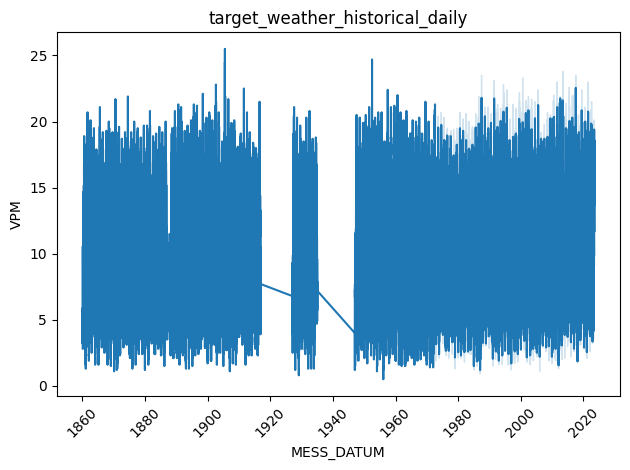

In [15]:
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = 'VPM', 'PM', 'TMK', 'UPM'
target = 'VPM'

simple_lineplot(df=KL_climate_df_dropcol, y=target)

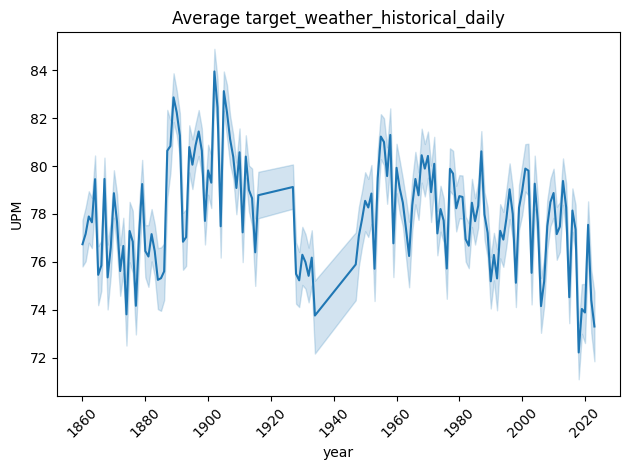

In [17]:
# Aggregate
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = 'VPM', 'PM', 'TMK', 'UPM'
target = 'UPM'

average_lineplot_no_group(df=KL_climate_df, y=target, x="MESS_DATUM", time='year')

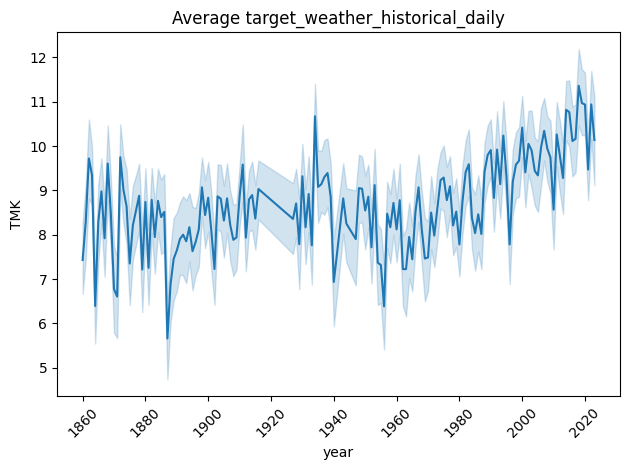

In [19]:
# Aggregate
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = 'VPM', 'PM', 'TMK', 'UPM'
target = 'TMK'
average_lineplot_no_group(df=KL_climate_df, y=target, x="MESS_DATUM", time='year')

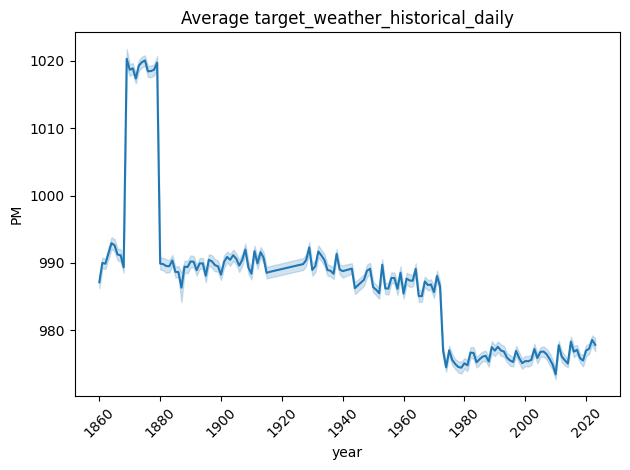

In [21]:
# Aggregate
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = 'VPM', 'PM', 'TMK', 'UPM'
target = 'PM'
average_lineplot_no_group(df=KL_climate_df, y=target, x="MESS_DATUM", time='year')

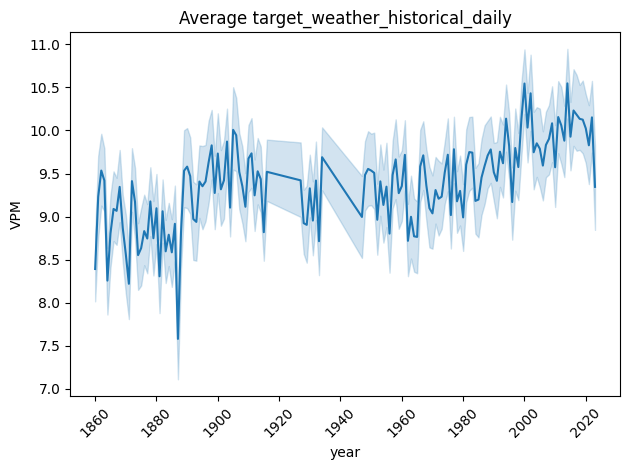

In [23]:
# Aggregate
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = 'VPM', 'PM', 'TMK', 'UPM'
target = 'VPM'
average_lineplot_no_group(df=KL_climate_df, y=target, x="MESS_DATUM", time='year')


### More Visualization

In [57]:
# missing value treatment for max temp for preparation
# KL_climate_df.txk = df_kn.KL_climate_df.replace(-999, np.nan)
KL_climate_df["color_tmk"] = KL_climate_df["TMK"].isna().astype(int)
KL_climate_df.color_tmk.value_counts()


color_tmk
0    73483
1     8614
Name: count, dtype: int64

In [60]:
# split data by city
df_gr = KL_climate_df[KL_climate_df["STATIONS_ID"]==1684].reset_index()
df_kn = KL_climate_df[KL_climate_df["STATIONS_ID"]==2712].reset_index()


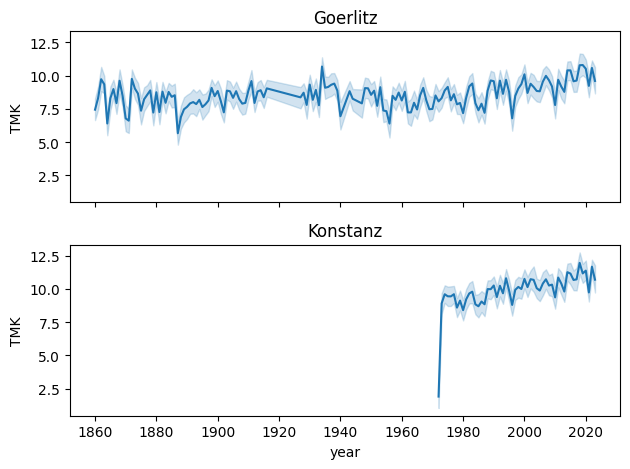

In [62]:
fig, ax = plt.subplots(2,1, sharey=True, sharex=True)
sns.lineplot(data=df_gr, x="year", y="TMK", ax=ax[0]).set(title="Goerlitz")
sns.lineplot(data=df_kn, x="year", y="TMK", ax=ax[1]).set(title="Konstanz")
fig.tight_layout()

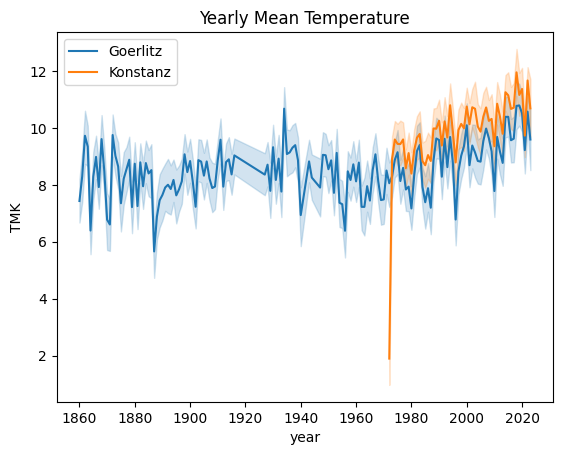

In [64]:
sns.lineplot(data=df_gr, x="year", y="TMK", label="Goerlitz")\
    .set(title="Yearly Mean Temperature")
sns.lineplot(data=df_kn, x="year", y="TMK", label="Konstanz")\
    .set(title="Yearly Mean Temperature")
plt.show()

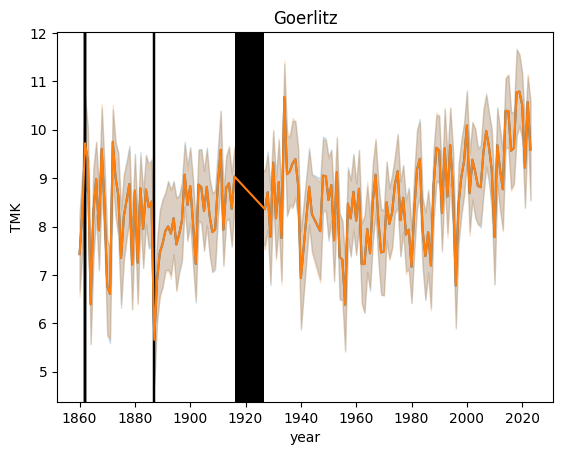

In [59]:
# plot indicating missing data
fig = sns.lineplot(data=df_gr, x="year", y="TMK")
for idx in range(len(df_gr.color_tmk)):
    if df_gr.color_tmk[idx] == 1: 
        fig.axvline(df_gr.year[idx], color="black", alpha=0.2)
sns.lineplot(data=df_gr, x="year", y="TMK").set(title="Goerlitz")
plt.show()


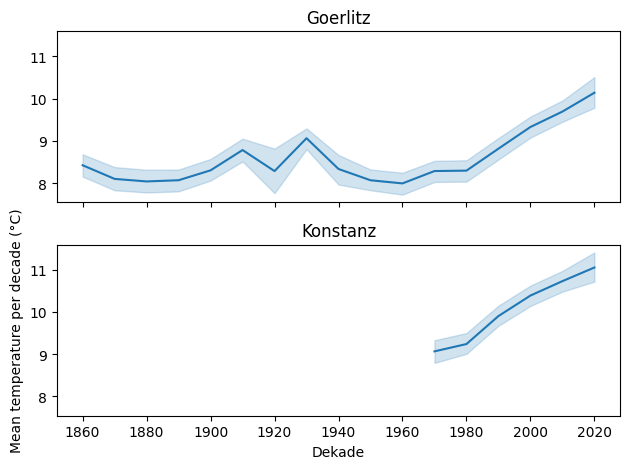

In [70]:
fig, ax = plt.subplots(2,1, sharey=True, sharex=True)
sns.lineplot(data=df_gr, x="decade", y="TMK", ax=ax[0])\
    .set(title="Goerlitz", ylabel=None)
sns.lineplot(data=df_kn, x="decade", y="TMK", ax=ax[1])\
    .set(xlabel="Dekade", ylabel="Mean temperature per decade (°C)", 
         title="Konstanz")
fig.tight_layout()

In [71]:
# decade-wise mean for yearly max temperature
# max of the decade
go_gr = df_gr.groupby("year").max().reset_index()
go_kn = df_kn.groupby("year").max().reset_index()

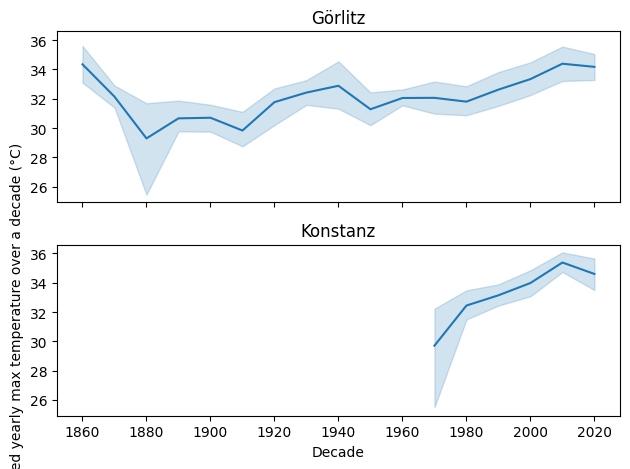

In [74]:
# decade-wise temperature development
fig, ax = plt.subplots(2,1, sharey=True, sharex=True)
sns.lineplot(data=go_gr, x="decade", y="TXK", ax=ax[0])\
    .set(xlabel="Decade", ylabel=None, 
         title="Görlitz")
sns.lineplot(data=go_kn, x="decade", y="TXK", ax=ax[1])\
    .set(xlabel="Decade", ylabel="Averaged yearly max temperature over a decade (°C)", 
         title="Konstanz")
fig.tight_layout()
plt.show()

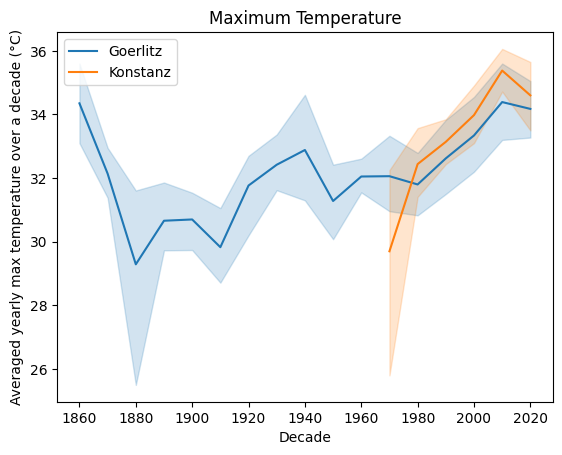

In [77]:
sns.lineplot(data=go_gr, x="decade", y="TXK", label="Goerlitz")\
    .set(xlabel="Decaade", ylabel="Averaged yearly max temperature over a decade (°C)", 
         title="Maximum Temperature")
sns.lineplot(data=go_kn, x="decade", y="TXK", label="Konstanz")\
    .set(xlabel="Decade", ylabel="Averaged yearly max temperature over a decade (°C)", 
         title="Maximum Temperature")
plt.show()

## 'phenomena_historical_daily' - data import and preprocessing 

In [24]:
#path_KL_climate_phenomena_historical_daily  = '../data/weather-daily/phenomena_historical_daily/*.txt'
txt_files =  sorted(glob.glob(path_KL_climate_phenomena_historical_), reverse=False)

# Create an empty list to store the data from each txt file
main_cph_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, sep = ";")#'ISO-8859-1')
    print(file, df.shape)
    # Append the DataFrame to the list
    main_cph_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
phenomena_historical_df = pd.concat(main_cph_df, ignore_index=False).reset_index(drop=True) #KL_climate_his = pd.concat(main_df, axis=1)
#phenomena_historical_df.to_csv('../data/Weather_phenomena_historical_daily.csv')

../data/weather-daily/phenomena_historical_daily/produkt_wetter_tag_18670730_20181231_01684.txt (48243, 13)
../data/weather-daily/phenomena_historical_daily/produkt_wetter_tag_19721101_20171231_02712.txt (16413, 13)
2
64656


In [25]:
# replace leading spaces in column titles
phenomena_historical_df.columns = phenomena_historical_df.columns.str.replace(" ", "")
phenomena_historical_df.columns, phenomena_historical_df.shape

(Index(['STATIONS_ID', 'MESS_DATUM', 'QN_4', 'NEBEL', 'GEWITTER', 'STURM_6',
        'STURM_8', 'TAU', 'GLATTEIS', 'REIF', 'GRAUPEL', 'HAGEL', 'eor'],
       dtype='object'),
 (64656, 13))

In [26]:
phenomena_historical_df.head()

,STATIONS_ID,MESS_DATUM,QN_4,NEBEL,GEWITTER,STURM_6,STURM_8,TAU,GLATTEIS,REIF,GRAUPEL,HAGEL,eor
0,1684,18670730,-999,-999,-999,-999,-999,-999,-999,-999,0,0,eor
1,1684,18670731,-999,-999,-999,-999,-999,-999,-999,-999,0,0,eor
2,1684,18670801,-999,-999,-999,-999,-999,-999,-999,-999,0,0,eor
3,1684,18670802,-999,-999,-999,-999,-999,-999,-999,-999,0,0,eor
4,1684,18670803,-999,-999,-999,-999,-999,-999,-999,-999,0,0,eor


In [27]:
phenomena_historical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64656 entries, 0 to 64655
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   STATIONS_ID  64656 non-null  int64 
 1   MESS_DATUM   64656 non-null  int64 
 2   QN_4         64656 non-null  int64 
 3   NEBEL        64656 non-null  int64 
 4   GEWITTER     64656 non-null  int64 
 5   STURM_6      64656 non-null  int64 
 6   STURM_8      64656 non-null  int64 
 7   TAU          64656 non-null  int64 
 8   GLATTEIS     64656 non-null  int64 
 9   REIF         64656 non-null  int64 
 10  GRAUPEL      64656 non-null  int64 
 11  HAGEL        64656 non-null  int64 
 12  eor          64656 non-null  object
dtypes: int64(12), object(1)
memory usage: 6.4+ MB


In [28]:
phenomena_historical_df.describe().T

,count,mean,std,min,25%,50%,75%,max
STATIONS_ID,64656.0,1.944959e+03,447.402883,1684.0,1684.00,1684.0,2712.0,2712.0
MESS_DATUM,64656.0,1.957261e+07,456057.614406,18670730.0,19150304.75,19740217.0,19960404.0,20181231.0
QN_4,64656.0,-3.563443e+02,484.101728,-999.0,-999.00,5.0,10.0,10.0
NEBEL,64656.0,-3.615594e+02,480.169743,-999.0,-999.00,0.0,0.0,1.0
GEWITTER,64656.0,-3.615922e+02,480.144959,-999.0,-999.00,0.0,0.0,1.0
STURM_6,64656.0,-3.615743e+02,480.158512,-999.0,-999.00,0.0,0.0,1.0
STURM_8,64656.0,-3.616375e+02,480.110792,-999.0,-999.00,0.0,0.0,1.0
TAU,64656.0,-3.614543e+02,480.248924,-999.0,-999.00,0.0,0.0,1.0
GLATTEIS,64656.0,-3.616046e+02,480.135675,-999.0,-999.00,0.0,0.0,1.0
REIF,64656.0,-3.615812e+02,480.153264,-999.0,-999.00,0.0,0.0,1.0


### Missing Values

In [29]:
# check for missing values
phenomena_historical_df.isnull().sum()

STATIONS_ID    0
MESS_DATUM     0
QN_4           0
NEBEL          0
GEWITTER       0
STURM_6        0
STURM_8        0
TAU            0
GLATTEIS       0
REIF           0
GRAUPEL        0
HAGEL          0
eor            0
dtype: int64

In [31]:
# -999 represents missing data
# convert -999 to NaN
for col in ['QN_4', 'NEBEL', 'GEWITTER', 'STURM_6',
            'STURM_8', 'TAU', 'GLATTEIS', 'REIF',]:
       phenomena_historical_df[col] = phenomena_historical_df[col].replace(-999, np.nan) 

In [32]:
# convert date into datetime format
phenomena_historical_df['MESS_DATUM'] = pd.to_datetime(phenomena_historical_df['MESS_DATUM'], format='%Y%m%d')

# Extract year, month and date from the datetime object
phenomena_historical_df['decade'] = phenomena_historical_df['MESS_DATUM'].dt.year//10*10
phenomena_historical_df['year'] = phenomena_historical_df['MESS_DATUM'].dt.year
phenomena_historical_df['month'] = phenomena_historical_df['MESS_DATUM'].dt.month
phenomena_historical_df['week'] = phenomena_historical_df['MESS_DATUM'].dt.isocalendar().week.astype('int32')
phenomena_historical_df['day'] = phenomena_historical_df['MESS_DATUM'].dt.day
phenomena_historical_df['dayofyear'] = phenomena_historical_df['MESS_DATUM'].dt.dayofyear
phenomena_historical_df.head()

,STATIONS_ID,MESS_DATUM,QN_4,NEBEL,GEWITTER,STURM_6,STURM_8,TAU,GLATTEIS,REIF,GRAUPEL,HAGEL,eor,decade,year,month,week,day,dayofyear
0,1684,1867-07-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,eor,1860,1867,7,31,30,211
1,1684,1867-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,eor,1860,1867,7,31,31,212
2,1684,1867-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,eor,1860,1867,8,31,1,213
3,1684,1867-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,eor,1860,1867,8,31,2,214
4,1684,1867-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,eor,1860,1867,8,31,3,215


### Drop columns from  weather-daily/phenomena_historical_daily

In [33]:
# columns pattern 
phenomena_historical_df_dropcol = phenomena_historical_df.drop(['eor', 'year', 'month', 'day', 'dayofyear'], axis=1)
phenomena_historical_df_dropcol.head()
#phenomena_historical_df_dropcol.to_csv('../data/Weather_phenomena_historical_daily.csv')


,STATIONS_ID,MESS_DATUM,QN_4,NEBEL,GEWITTER,STURM_6,STURM_8,TAU,GLATTEIS,REIF,GRAUPEL,HAGEL,decade,week
0,1684,1867-07-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1860,31
1,1684,1867-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1860,31
2,1684,1867-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1860,31
3,1684,1867-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1860,31
4,1684,1867-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1860,31


### Visualization

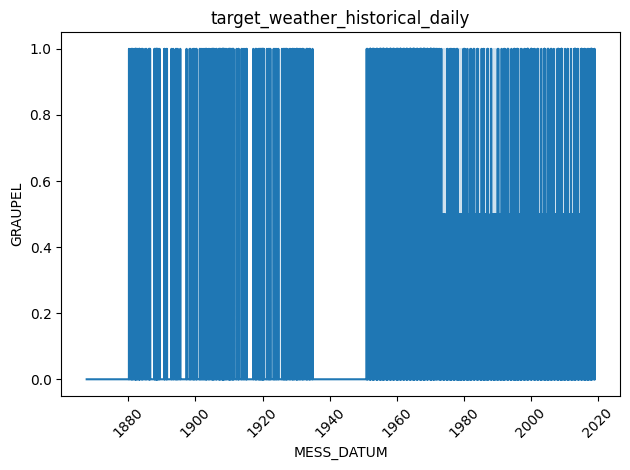

In [34]:
# 1. Columns pattern 'QN_4', 'NEBEL', 'GEWITTER', 'STURM_6', 'STURM_8', 'TAU', 'GLATTEIS', 'REIF', 
# 2. Columns pattern 'GRAUPEL', 'HAGEL'
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = 'GRAUPEL', 'HAGEL'
target = 'GRAUPEL'
simple_lineplot(df=phenomena_historical_df, y=target)

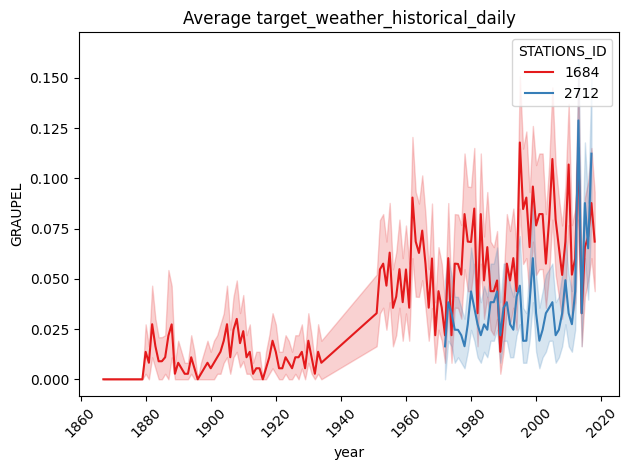

In [35]:
# Aggregate 
# 1. Columns pattern 'QN_4', 'NEBEL', 'GEWITTER', 'STURM_6', 'STURM_8', 'TAU', 'GLATTEIS', 'REIF', 
# 2. Columns pattern 'GRAUPEL', 'HAGEL'
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = 'GRAUPEL', 'HAGEL'
target = 'GRAUPEL'
average_lineplot(df=phenomena_historical_df, y=target, x="MESS_DATUM", time='year')

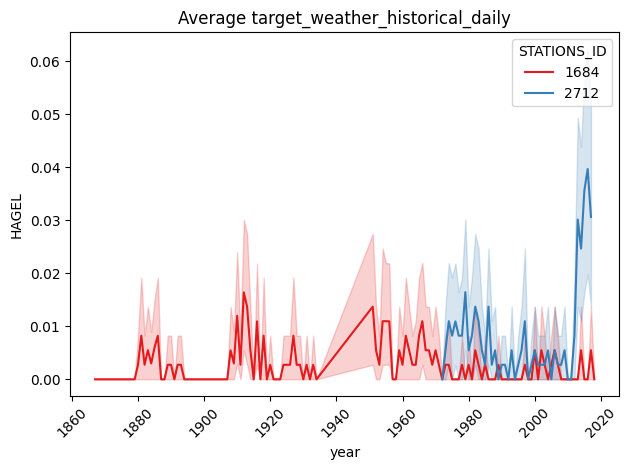

In [36]:
# Aggregate 
# 1. Columns pattern 'QN_4', 'NEBEL', 'GEWITTER', 'STURM_6', 'STURM_8', 'TAU', 'GLATTEIS', 'REIF', 
# 2. Columns pattern 'GRAUPEL', 'HAGEL'
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = 'GRAUPEL', 'HAGEL'
target = 'HAGEL'
average_lineplot(df=phenomena_historical_df, y=target, x="MESS_DATUM", time='year')

In [37]:
phenomena_historical_df.index.is_unique
phenomena_historical_df.columns.is_unique

True

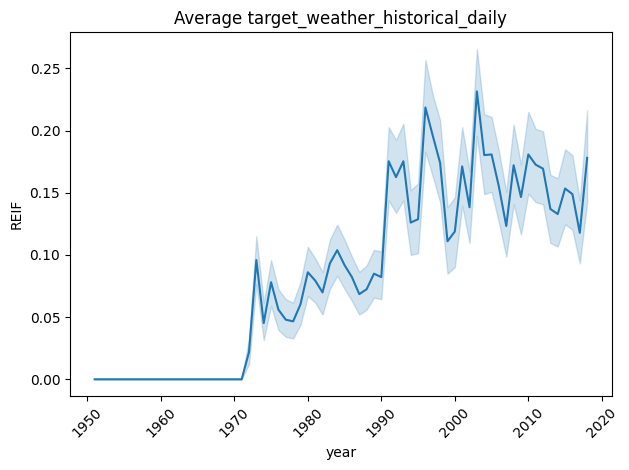

In [38]:
# Aggregate 
# Columns pattern 'QN_4', 'NEBEL', 'GEWITTER', 'STURM_6', 'STURM_8', 'TAU', 'GLATTEIS', 'REIF', 
# Columns pattern 'GRAUPEL', 'HAGEL'
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = 'GRAUPEL', 'HAGEL'
target = 'REIF'
average_lineplot_no_group(df=phenomena_historical_df, y=target, x="MESS_DATUM", time='year')

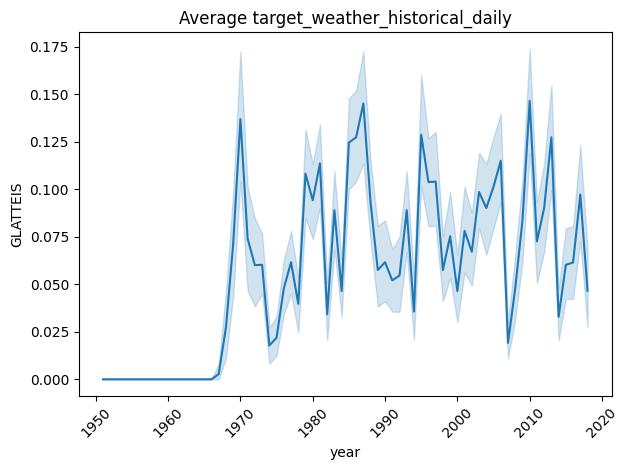

In [39]:
# Aggregate 
#1. Columns pattern 'QN_4', 'NEBEL', 'GEWITTER', 'STURM_6', 'STURM_8', 'TAU', 'GLATTEIS', 'REIF', 
#2. Columns pattern 'GRAUPEL', 'HAGEL'
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = 'GRAUPEL', 'HAGEL'
target = 'GLATTEIS'
average_lineplot_no_group(df=phenomena_historical_df, y=target, x="MESS_DATUM", time='year')

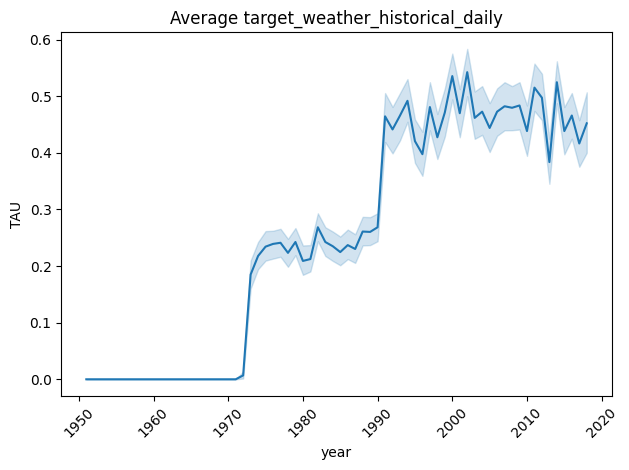

In [40]:
# Aggregate 
# Columns pattern 'QN_4', 'NEBEL', 'GEWITTER', 'STURM_6', 'STURM_8', 'TAU', 'GLATTEIS', 'REIF', 
# Columns pattern 'GRAUPEL', 'HAGEL'
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = 'GRAUPEL', 'HAGEL'
target = 'TAU'
average_lineplot_no_group(df=phenomena_historical_df, y=target, x="MESS_DATUM", time='year')

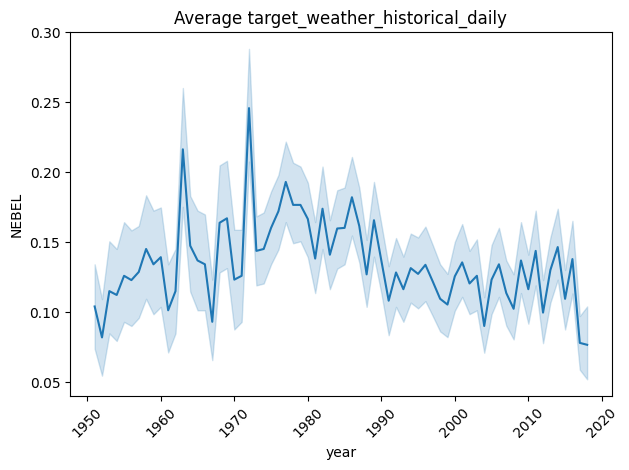

In [41]:
# Aggregate 
# 1. Columns pattern 'QN_4', 'NEBEL', 'GEWITTER', 'STURM_6', 'STURM_8', 'TAU', 'GLATTEIS', 'REIF', 
# 2. Columns pattern 'GRAUPEL', 'HAGEL'
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = 'GRAUPEL', 'HAGEL'
target = 'NEBEL'
average_lineplot_no_group(df=phenomena_historical_df, y=target, x="MESS_DATUM", time='year')

## 'phenomena_recent_daily' - missing

In [42]:
# no data available
# path_KL_climate_phenomena_recent_daily = '../data/weather-daily/phenomena_recent_daily/*.txt'

## 'RR_morephenomena_historical_daily' - data import and preprocessing 

In [43]:
#path_KL_climate_morephenomena_historical_daily  = '../data/weather-daily/RR_morephenomena_historical_daily/*.txt'
txt_files =  sorted(glob.glob(path_KL_climate_morephenomena_historical_), reverse=False)

# Create an empty list to store the data from each txt file
main_RRcmh_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, sep = ";")#'ISO-8859-1')
    print(file, df.shape)
    # Append the DataFrame to the list
    main_RRcmh_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
RR_morephenomena_historical_df = pd.concat(main_RRcmh_df, ignore_index=False).reset_index(drop=True) #KL_climate_his = pd.concat(main_df, axis=1)
#RR_morephenomena_historical_df.to_csv('../data/Weather_RR_morephenomena_historical_daily.csv')

../data/weather-daily/RR_morephenomena_historical_daily/produkt_rr_wetter_tag_18670729_20181231_01684.txt (40723, 8)
../data/weather-daily/RR_morephenomena_historical_daily/produkt_rr_wetter_tag_19721101_20171231_02712.txt (15826, 8)
2
56549


In [44]:
# replace leading spaces in column titles
RR_morephenomena_historical_df.columns = RR_morephenomena_historical_df.columns.str.replace(" ", "")
RR_morephenomena_historical_df.columns, RR_morephenomena_historical_df.shape

(Index(['STATIONS_ID', 'MESS_DATUM', 'QN_6', 'RR_GRAUPEL', 'RR_HAGEL',
        'RR_NEBEL', 'RR_GEWITTER', 'eor'],
       dtype='object'),
 (56549, 8))

In [45]:
RR_morephenomena_historical_df.head()

,STATIONS_ID,MESS_DATUM,QN_6,RR_GRAUPEL,RR_HAGEL,RR_NEBEL,RR_GEWITTER,eor
0,1684,18670729,1,0,0,0,0,eor
1,1684,18670730,1,0,0,0,0,eor
2,1684,18670731,1,0,0,0,0,eor
3,1684,18670801,1,0,0,0,0,eor
4,1684,18670802,1,0,0,0,0,eor


In [46]:
RR_morephenomena_historical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56549 entries, 0 to 56548
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   STATIONS_ID  56549 non-null  int64 
 1   MESS_DATUM   56549 non-null  int64 
 2   QN_6         56549 non-null  int64 
 3   RR_GRAUPEL   56549 non-null  int64 
 4   RR_HAGEL     56549 non-null  int64 
 5   RR_NEBEL     56549 non-null  int64 
 6   RR_GEWITTER  56549 non-null  int64 
 7   eor          56549 non-null  object
dtypes: int64(7), object(1)
memory usage: 3.5+ MB


In [47]:
RR_morephenomena_historical_df.describe().T

,count,mean,std,min,25%,50%,75%,max
STATIONS_ID,56549.0,1.971700e+03,461.506145,1684.0,1684.0,1684.0,2712.0,2712.0
MESS_DATUM,56549.0,1.953800e+07,478200.299936,18670729.0,19090615.0,19621130.0,19990112.0,20181231.0
QN_6,56549.0,5.045695e+00,3.747188,1.0,1.0,5.0,9.0,10.0
RR_GRAUPEL,56549.0,3.531451e-02,0.184575,0.0,0.0,0.0,0.0,1.0
RR_HAGEL,56549.0,3.625175e-02,0.186918,0.0,0.0,0.0,0.0,1.0
RR_NEBEL,56549.0,3.734814e-02,0.189615,0.0,0.0,0.0,0.0,1.0
RR_GEWITTER,56549.0,3.955861e-02,0.194922,0.0,0.0,0.0,0.0,1.0


### Missing Values

In [48]:
# check for missing values
RR_morephenomena_historical_df.isnull().sum()

STATIONS_ID    0
MESS_DATUM     0
QN_6           0
RR_GRAUPEL     0
RR_HAGEL       0
RR_NEBEL       0
RR_GEWITTER    0
eor            0
dtype: int64

In [49]:
# convert date into datetime format
RR_morephenomena_historical_df['MESS_DATUM'] = pd.to_datetime(RR_morephenomena_historical_df['MESS_DATUM'], format='%Y%m%d')

# Extract year, month and date from the datetime object
RR_morephenomena_historical_df['decade'] = RR_morephenomena_historical_df['MESS_DATUM'].dt.year//10*10
RR_morephenomena_historical_df['year'] = RR_morephenomena_historical_df['MESS_DATUM'].dt.year
RR_morephenomena_historical_df['month'] = RR_morephenomena_historical_df['MESS_DATUM'].dt.month
RR_morephenomena_historical_df['week'] = RR_morephenomena_historical_df['MESS_DATUM'].dt.isocalendar().week.astype('int32')
RR_morephenomena_historical_df['day'] = RR_morephenomena_historical_df['MESS_DATUM'].dt.day
RR_morephenomena_historical_df['dayofyear'] = RR_morephenomena_historical_df['MESS_DATUM'].dt.dayofyear
RR_morephenomena_historical_df.head()

,STATIONS_ID,MESS_DATUM,QN_6,RR_GRAUPEL,RR_HAGEL,RR_NEBEL,RR_GEWITTER,eor,decade,year,month,week,day,dayofyear
0,1684,1867-07-29,1,0,0,0,0,eor,1860,1867,7,31,29,210
1,1684,1867-07-30,1,0,0,0,0,eor,1860,1867,7,31,30,211
2,1684,1867-07-31,1,0,0,0,0,eor,1860,1867,7,31,31,212
3,1684,1867-08-01,1,0,0,0,0,eor,1860,1867,8,31,1,213
4,1684,1867-08-02,1,0,0,0,0,eor,1860,1867,8,31,2,214


### Drop columns from  RR_morephenomena_historical_daily

In [50]:
# columns pattern 
RR_morephenomena_historical_df_dropcol = RR_morephenomena_historical_df.drop(['eor', 'year', 'month', 'day', 'dayofyear'], axis=1)
RR_morephenomena_historical_df_dropcol.head()
#RR_morephenomena_historical_df_dropcol.to_csv('../data/Weather_RR_morephenomena_historical_daily.csv')

,STATIONS_ID,MESS_DATUM,QN_6,RR_GRAUPEL,RR_HAGEL,RR_NEBEL,RR_GEWITTER,decade,week
0,1684,1867-07-29,1,0,0,0,0,1860,31
1,1684,1867-07-30,1,0,0,0,0,1860,31
2,1684,1867-07-31,1,0,0,0,0,1860,31
3,1684,1867-08-01,1,0,0,0,0,1860,31
4,1684,1867-08-02,1,0,0,0,0,1860,31


### Visualization

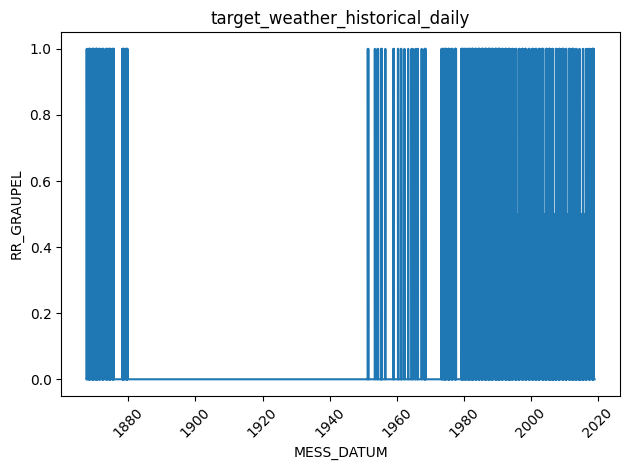

In [51]:
# Columns pattern QN_6	
# Columns pattern  RR_GRAUPEL	RR_HAGEL	
# Columns pattern RR_NEBEL	RR_GEWITTER
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = RR_GRAUPEL	RR_HAGEL
target = 'RR_GRAUPEL'
simple_lineplot(df=RR_morephenomena_historical_df, y=target)

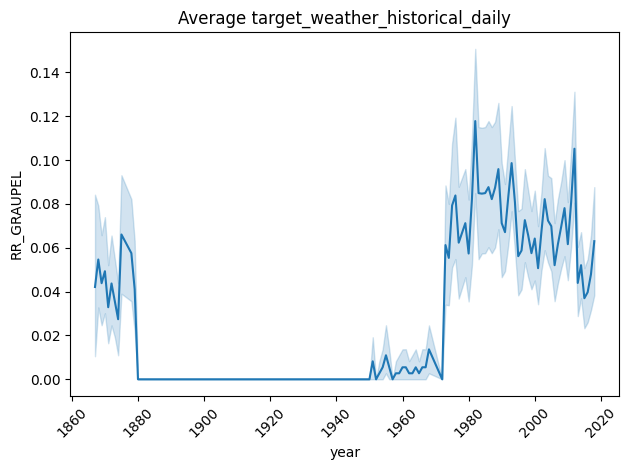

In [52]:
# Aggregate 
# 1. Columns pattern QN_6	
# 2.  Columns pattern  RR_GRAUPEL	RR_HAGEL	
# 3. Columns pattern RR_NEBEL	RR_GEWITTER
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = RR_GRAUPEL	RR_HAGEL
target = 'RR_GRAUPEL'
average_lineplot_no_group(df=RR_morephenomena_historical_df, y=target, x="MESS_DATUM", time='year')

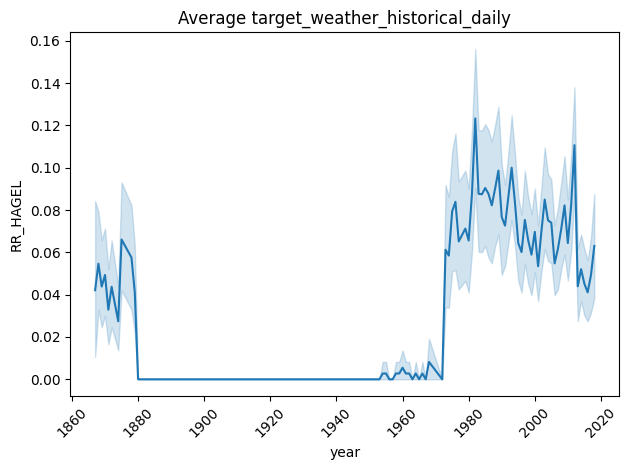

In [53]:
# Aggregate 
# 1. Columns pattern QN_6	
# 2. Columns pattern  RR_GRAUPEL	RR_HAGEL	
# 3. Columns pattern RR_NEBEL	RR_GEWITTER
# Potential target columns
#target_x = 'MESS_DATUM', 'year', 'month', 'day', 'dayofyear'
#target_y = RR_GRAUPEL	RR_HAGEL
target = 'RR_HAGEL'
average_lineplot_no_group(df=RR_morephenomena_historical_df, y=target, x="MESS_DATUM", time='year')

## 'RR_morephenomena_recent_daily' - missing 

In [54]:
# path_KL_climate_morephenomena_recent_daily  = '../data/weather-daily/RR_morephenomena_recent_/*.txt'
# no data available